1. Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_path = "music_tours.csv"
df = pd.read_csv(file_path)


Menampilkan Metadata Dataset

In [2]:
print("\nMetadata Dataset:")
print(df.info())


Metadata Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   Rank                              20 non-null     int64 
 1   Peak                              9 non-null      object
 2   All Time Peak                     6 non-null      object
 3   Actual gross                      20 non-null     object
 4   Adjusted gross (in 2022 dollars)  20 non-null     object
 5   Artist                            20 non-null     object
 6   Tour title                        20 non-null     object
 7   Year(s)                           20 non-null     object
 8   Shows                             20 non-null     int64 
 9   Average gross                     20 non-null     object
 10  Ref.                              20 non-null     object
dtypes: int64(2), object(9)
memory usage: 1.8+ KB
None


In [3]:
print("\nDeskripsi Singkat Dataset:")
print(df.describe())


Deskripsi Singkat Dataset:
            Rank       Shows
count  20.000000   20.000000
mean   10.450000  110.000000
std     5.942488   66.507617
min     1.000000   41.000000
25%     5.750000   59.000000
50%    10.500000   87.000000
75%    15.250000  134.500000
max    20.000000  325.000000


In [4]:
print("\nPreview Data:")
df.head(5)


Preview Data:


,Rank,Peak,All Time Peak,Actual gross,Adjusted gross (in 2022 dollars),Artist,Tour title,Year(s),Shows,Average gross,Ref.
0,1,1,2,"$780,000,000","$780,000,000",Taylor Swift,The Eras Tour †,2023–2024,56,"$13,928,571",[1]
1,2,1,7[2],"$579,800,000","$579,800,000",Beyoncé,Renaissance World Tour,2023,56,"$10,353,571",[3]
2,3,1[4],2[5],"$411,000,000","$560,622,615",Madonna,Sticky & Sweet Tour ‡[4][a],2008–2009,85,"$4,835,294",[6]
3,4,2[7],10[7],"$397,300,000","$454,751,555",Pink,Beautiful Trauma World Tour,2018–2019,156,"$2,546,795",[7]
4,5,2[4],NaN,"$345,675,146","$402,844,849",Taylor Swift,Reputation Stadium Tour,2018,53,"$6,522,173",[8]


In [17]:
df.drop(['All Time Peak', 'Rank'], axis=1, inplace=True)

In [18]:
df.head(5)

,Actual gross,Adjusted gross (in 2022 dollars),Artist,Tour title,Year(s),Shows,Average gross,Ref.
0,"$780,000,000","$780,000,000",Taylor Swift,The Eras Tour †,2023–2024,56,"$13,928,571",[1]
1,"$579,800,000","$579,800,000",Beyoncé,Renaissance World Tour,2023,56,"$10,353,571",[3]
2,"$411,000,000","$560,622,615",Madonna,Sticky & Sweet Tour ‡[4][a],2008–2009,85,"$4,835,294",[6]
3,"$397,300,000","$454,751,555",Pink,Beautiful Trauma World Tour,2018–2019,156,"$2,546,795",[7]
4,"$345,675,146","$402,844,849",Taylor Swift,Reputation Stadium Tour,2018,53,"$6,522,173",[8]


# 2. Data Cleaning: Mengecek Nilai Null dan Duplikasi Data

In [ ]:
def check_missing_and_duplicates(df):
    print("\nMissing Values:")
    print(df.isnull().sum())
    print("\nDuplicated Rows:", df.duplicated().sum())

check_missing_and_duplicates(df)


Missing Values:
Rank                                 0
Peak                                11
All Time Peak                       14
Actual gross                         0
Adjusted gross (in 2022 dollars)     0
Artist                               0
Tour title                           0
Year(s)                              0
Shows                                0
Average gross                        0
Ref.                                 0
dtype: int64

Duplicated Rows: 0


Handling Missing Values

In [11]:
df_cleaned = df.fillna(df.median(numeric_only=True))
df_cleaned = df_cleaned.fillna(df_cleaned.mode().iloc[0])

Drop duplicate rows

In [8]:
df_cleaned = df_cleaned.drop_duplicates()

print("\nSetelah pembersihan:")
check_missing_and_duplicates(df_cleaned)


Setelah pembersihan:

Missing Values:
Rank                                0
Peak                                0
All Time Peak                       0
Actual gross                        0
Adjusted gross (in 2022 dollars)    0
Artist                              0
Tour title                          0
Year(s)                             0
Shows                               0
Average gross                       0
Ref.                                0
dtype: int64

Duplicated Rows: 0


# 3. Business Questions Analysis

Rata-rata harga tiket konser

In [9]:
df_cleaned["Average gross"] = df_cleaned["Average gross"].replace('[\$,]', '', regex=True).astype(float)

In [10]:
average_gross = df_cleaned["Average gross"].mean()
formatted_average = f"${average_gross:,.2f}"
print(formatted_average)

$3,726,571.15


In [11]:
print(df_cleaned["Artist"].value_counts().head(5))

Artist
Taylor Swift    4
Madonna         4
Beyoncé         3
Pink            3
Lady Gaga       2
Name: count, dtype: int64


In [12]:
print(df_cleaned["Year(s)"].value_counts().head(5))

Year(s)
2013–2014    3
2023–2024    2
2008–2009    2
2023         1
2018         1
Name: count, dtype: int64


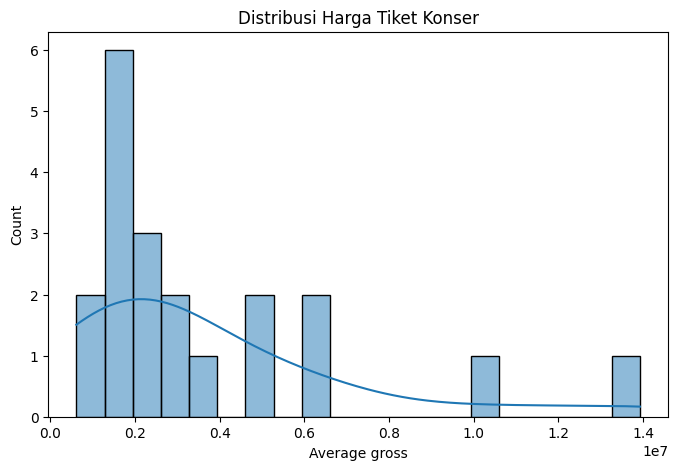

In [13]:
plt.figure(figsize=(8, 5))
sns.histplot(df_cleaned["Average gross"], bins=20, kde=True)
plt.title("Distribusi Harga Tiket Konser")
plt.show()

In [14]:
df_cleaned['Year(s)'] = df_cleaned['Year(s)'].str.split('–').str[0]

In [15]:
df_cleaned['Year(s)'] = pd.to_datetime(df_cleaned['Year(s)'], format='%Y')

C:\Users\Faliq\AppData\Local\Temp\ipykernel_25920\1216628849.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='month', data=df_cleaned, palette='viridis')


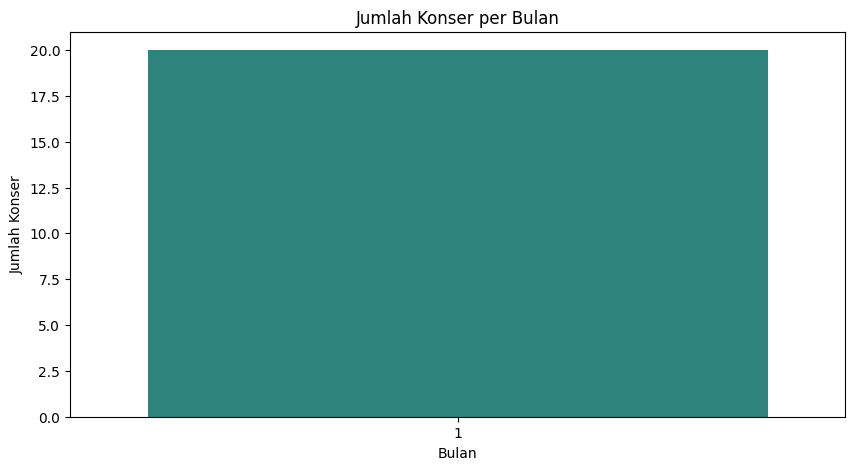

In [16]:
df_cleaned['Year(s)'] = pd.to_datetime(df_cleaned['Year(s)'], format='%Y')
df_cleaned['month'] = df_cleaned['Year(s)'].dt.month
plt.figure(figsize=(10, 5))
sns.countplot(x='month', data=df_cleaned, palette='viridis')
plt.title("Jumlah Konser per Bulan")
plt.xlabel("Bulan")
plt.ylabel("Jumlah Konser")
plt.show()

4. Statistik Deskriptif & Outlier Detection

In [17]:
print(df_cleaned.describe())

            Rank              Year(s)       Shows  Average gross  month
count  20.000000                   20   20.000000   2.000000e+01   20.0
mean   10.450000  2013-11-07 01:12:00  110.000000   3.726571e+06    1.0
min     1.000000  2002-01-01 00:00:00   41.000000   6.153850e+05    1.0
25%     5.750000  2011-04-02 06:00:00   59.000000   1.647508e+06    1.0
50%    10.500000  2013-07-02 12:00:00   87.000000   2.342100e+06    1.0
75%    15.250000  2016-07-01 18:00:00  134.500000   4.933024e+06    1.0
max    20.000000  2023-01-01 00:00:00  325.000000   1.392857e+07    1.0
std     5.942488                  NaN   66.507617   3.393340e+06    0.0


Boxplot untuk mendeteksi outlier harga tiket

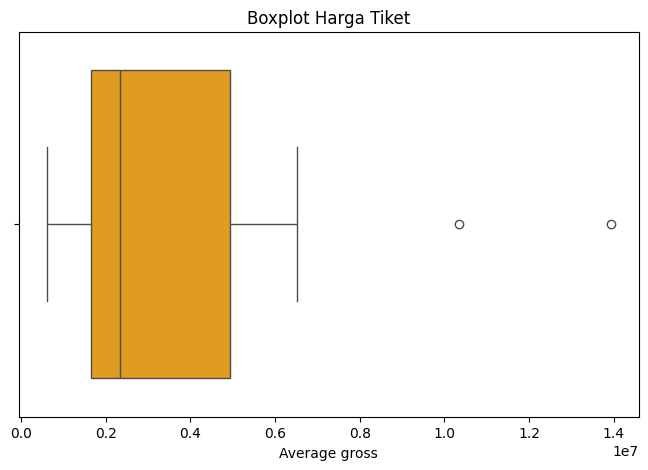

In [18]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df_cleaned["Average gross"], color='orange')
plt.title("Boxplot Harga Tiket")
plt.show()

Menampilkan outlier berdasarkan IQR

In [19]:
Q1 = df_cleaned['Average gross'].quantile(0.25)
Q3 = df_cleaned['Average gross'].quantile(0.75)
IQR = Q3 - Q1
outliers = df_cleaned[(df_cleaned['Average gross'] < (Q1 - 1.5 * IQR)) | (df_cleaned['Average gross'] > (Q3 + 1.5 * IQR))]
print("\nJumlah Outlier Harga Tiket:", len(outliers))


Jumlah Outlier Harga Tiket: 2


Kegiatan 2 - Data Visualization

Comparison: Perbandingan Rata-rata Pendapatan Konser Antar Artis

In [20]:
# Membersihkan nama kolom dengan regex (menghapus semua jenis spasi)
df_cleaned.columns = df_cleaned.columns.str.replace(r'\s+', '_', regex=True)

# Periksa kembali nama kolom
print(df_cleaned.columns)

Index(['Rank', 'Peak', 'All_Time_Peak', 'Actual_gross',
       'Adjusted_gross_(in_2022_dollars)', 'Artist', 'Tour_title', 'Year(s)',
       'Shows', 'Average_gross', 'Ref.', 'month'],
      dtype='object')


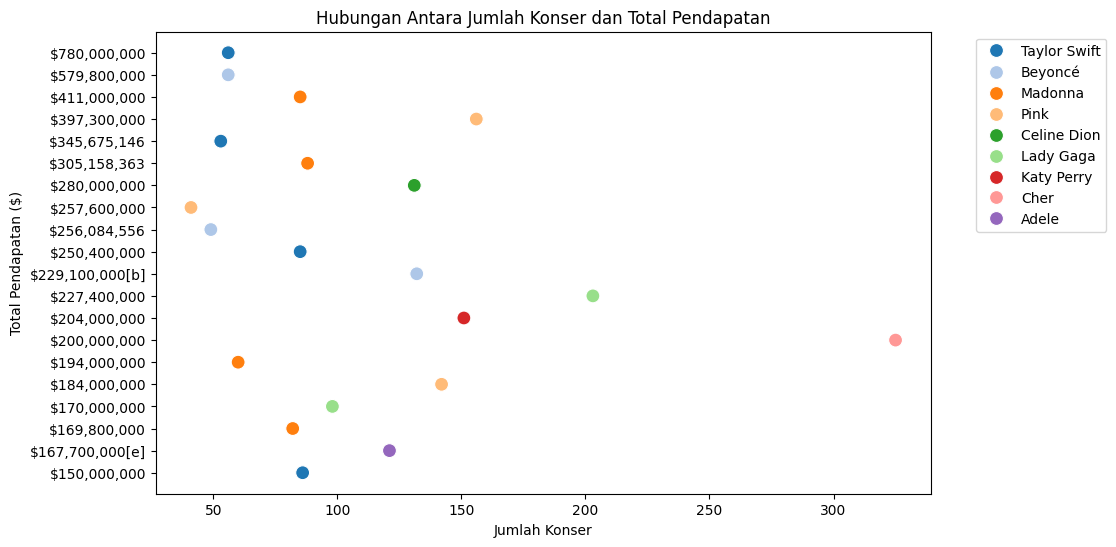

In [21]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x="Shows", y="Actual_gross", data=df_cleaned, hue="Artist", palette="tab20", s=100)
plt.title("Hubungan Antara Jumlah Konser dan Total Pendapatan")
plt.xlabel("Jumlah Konser")
plt.ylabel("Total Pendapatan ($)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

Distribution: Distribusi Harga Tiket Konser

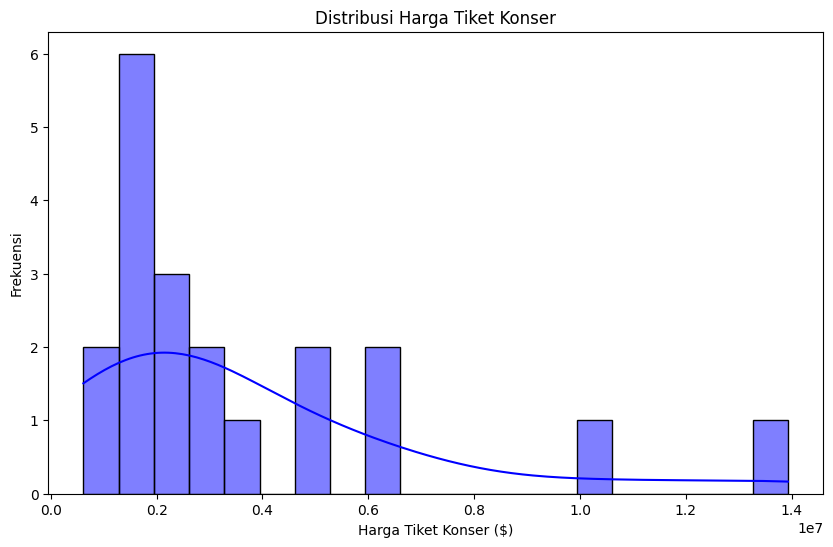

In [22]:
plt.figure(figsize=(10, 6))
sns.histplot(df_cleaned["Average_gross"], bins=20, kde=True, color="blue")
plt.title("Distribusi Harga Tiket Konser")
plt.xlabel("Harga Tiket Konser ($)")
plt.ylabel("Frekuensi")
plt.show()